## C S 329E HW 11

# Add YOUR NAMES HERE!

## C S 329E HW 11

# Hierarchical Clustering and Cluster Evaluation

## Your name here (and your partner's name if you are working in a pair)

As we are well into November, let us consider presidential elections of years past and do some exploratory grouping of states based on the 2008,2012, and 2016 presidential elections results.  The data we have is from the [The American Presidency Project](https://www.presidency.ucsb.edu/statistics/elections) and split into two files:

  - `votes_by_state.csv` => has the raw number of ballots cast for each of the top presidential candidates from 2008-2012 by US State (and the District of Columbia)
  - `republican_percentage_by_state.csv` => has the percentage of votes that were for the Republican candidate for 2008, 2012, and 2016 by US State (and the District of Columbia)
  
Our job is to group together states using different hierarchical agglomerative methodologies and compare the results.  You can imagine how finding states that tend to vote similarly to each other might be useful for election predictions, or for identifying swing states as part of a political campaign to invest in.

In [2]:
# Do not modify import block, all necessary imports are included

# Our regular libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

# This is for our hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform

# For our k-means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples

## Q1 - Using Different Proximity Functions

There is another scientific python library we haven't used much, SciPy, which has [library for hierarchical clustering](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html#scipy.cluster.hierarchy.linkage) and for [plotting dendrograms](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.dendrogram.html#scipy.cluster.hierarchy.dendrogram). 

Use these libraries to plot the hierarchical clusters formed from the raw vote count (`votes_by_state.csv`) using three different proximity measures:
  - Ward
  - Min
  - Max
  
The x-axis of the dendrogram should be labeled using the state name (and not the index of the state in the data frame).  The title should reflect what proximity measure you used to create the clusters.  In this use case only the number of votes cast are attributes, and the State names are the labels on that row of data.

Note, to make the plot legible you will have to change the plot size.  I found `figsize=(12,8)` worked well for me, but your mileage may vary depending on your setup. 

In [3]:
# Load the data, save off the state names into another series and just leave the attributes.
df_X = pd.read_csv('votes_by_state.csv')
s_states = df_X['State']
df_X = df_X.drop(columns=['State'])

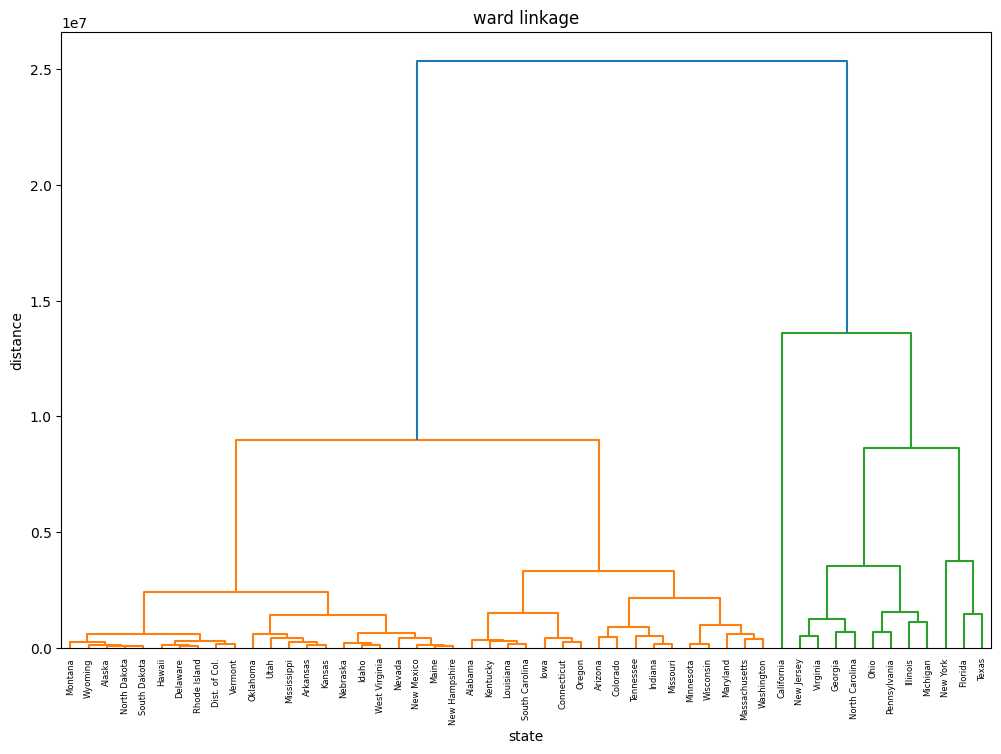

In [4]:
# Plot the dendrogram for the Ward proximity measure
# Load the data, save off the state names into another series and just leave the attributes.
df_X = pd.read_csv('votes_by_state.csv')
s_states = df_X['State']
df_X = df_X.drop(columns=['State'])

# %%
# Plot the dendrogram for the Ward proximity measure
plt.figure(figsize=(12, 8))
ward = linkage(df_X, method='ward')

dendrogram(ward, labels=s_states.values, leaf_rotation=90)
plt.title("ward linkage")
plt.xlabel("state")
plt.ylabel("distance")
plt.show()





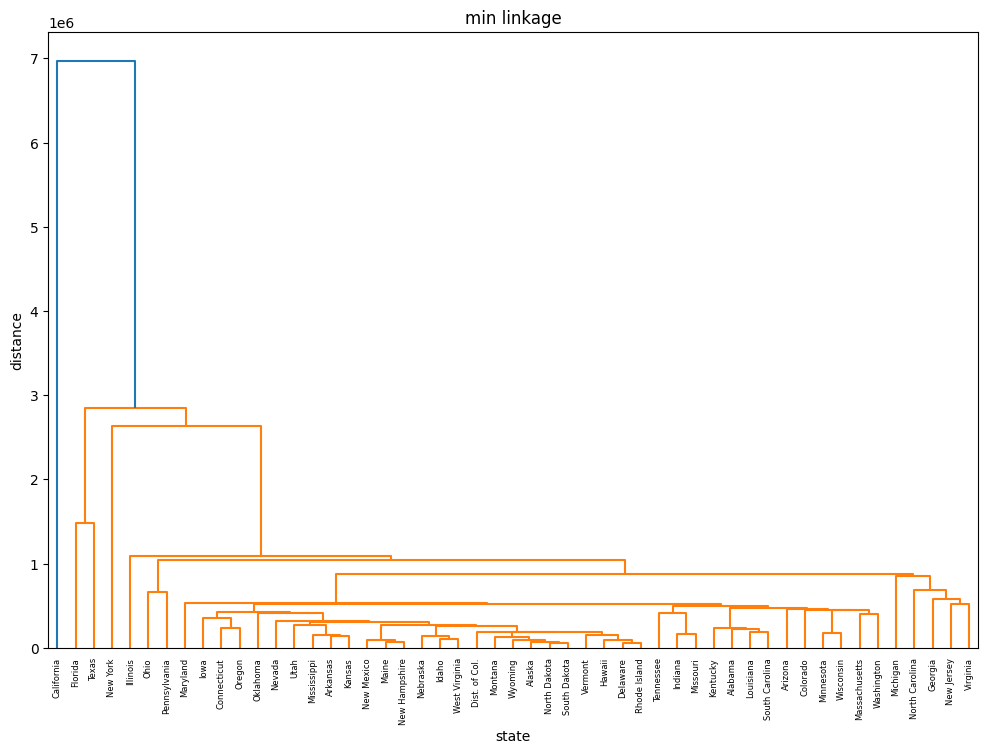

In [5]:
# Plot the dendrogram for the min proximity measure

# %%
# Plot the dendrogram for the min proximity measure
plt.figure(figsize=(12, 8))
min = linkage(df_X, method='single')

dendrogram(min, labels=s_states.values, leaf_rotation=90)
plt.title("min linkage")
plt.xlabel("state")
plt.ylabel("distance")
plt.show()



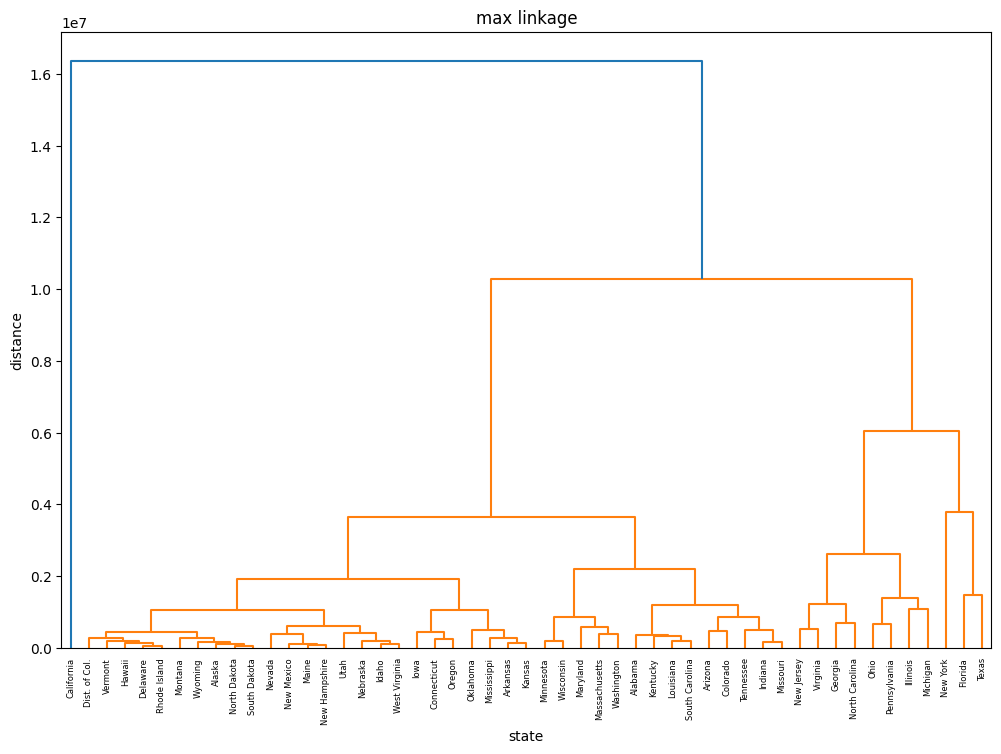

In [6]:
# Plot the dendrogram for the max proximity measure

# %%
# Plot the dendrogram for the max proximity measure
plt.figure(figsize=(12, 8))
max = linkage(df_X, method='complete')

dendrogram(max, labels=s_states.values, leaf_rotation=90)
plt.title("max linkage")
plt.xlabel("state")
plt.ylabel("distance")
plt.show()

## Q2 - Using Different Proximity Functions (part 2)

What is happening?  Even if you aren't a big politics wonk, you might find it strange that New York is closer to Texas than it is to California in all of those graphs!! You may think to yourself, "Self, how could this be?" You also might notice that Montana, Wyoming, and Alaska all tend to cluster together in all of these scenarios. 

At this point, your data science brain might be noticing that the _population_ of that state seems to be more important than which party _won_ the state.  You decide to engineer the data such that you reduce the dimensions down from 7 attributes, to 3 attributes, where each column is the _percentage_ of votes that were cast to the Republican candidate, and a 4th attribute indicating the range of percentages across the 3 elections.  I went ahead and did this for you, and created the file `republican_percentage_by_state.csv`. 

Plot the hierarchical clusters formed from percentage of ballots cast by Republicans (`republican_percentage_by_state.csv`) using three different proximity measures:
  - Ward
  - Min
  - Max
  
The x-axis of the dendrogram should be labeled using the state name (and not the index of the state in the data frame).  The title should reflect what proximity measure you used to create the clusters.  In this use case only the number of votes cast are attributes, and the State names are the labels on that row of data.

Note, to make the plot legible you will have to change the plot size.  I found `figsize=(12,8)` worked well for me, but your mileage may vary depending on your setup. 

In [7]:
# Load the data, save off the state names into another series and just leave the attributes.
df_X = pd.read_csv('republican_percentage_by_state.csv')
s_states = df_X['State']
df_X = df_X.drop(columns=['State'])

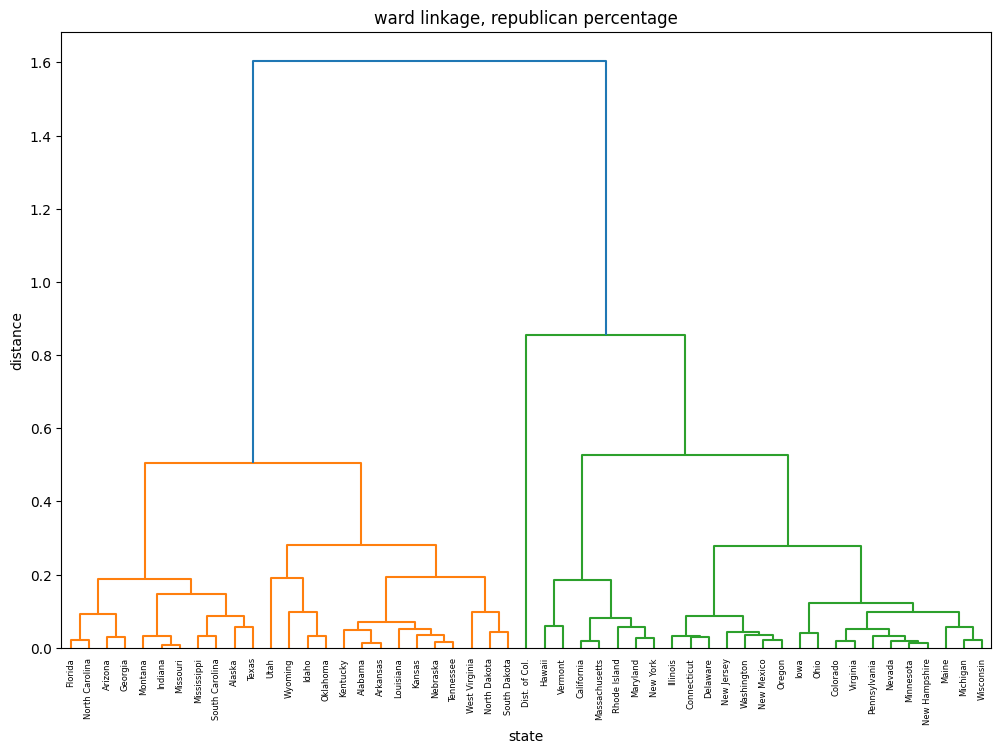

In [8]:
# Plot the dendrogram for the Ward proximity measure

# %%
# Plot the dendrogram for the Ward proximity measure
plt.figure(figsize=(12, 8))
ward = linkage(df_X, method='ward')

dendrogram(ward, labels=s_states.values, leaf_rotation=90)
plt.title("ward linkage, republican percentage")
plt.xlabel("state")
plt.ylabel("distance")
plt.show()



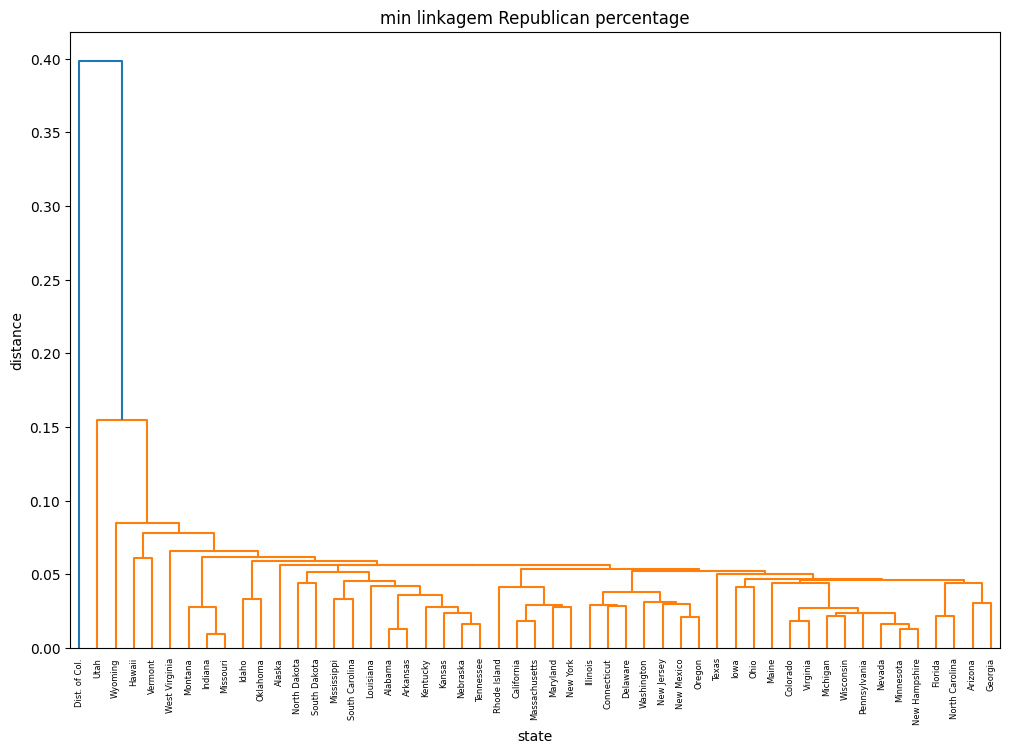

In [9]:
# Plot the dendrogram for the min proximity measure

# %%
# Plot the dendrogram for the min proximity measure
plt.figure(figsize=(12, 8))
min = linkage(df_X, method='single')

dendrogram(min, labels=s_states.values, leaf_rotation=90)
plt.title("min linkagem Republican percentage")
plt.xlabel("state")
plt.ylabel("distance")
plt.show()

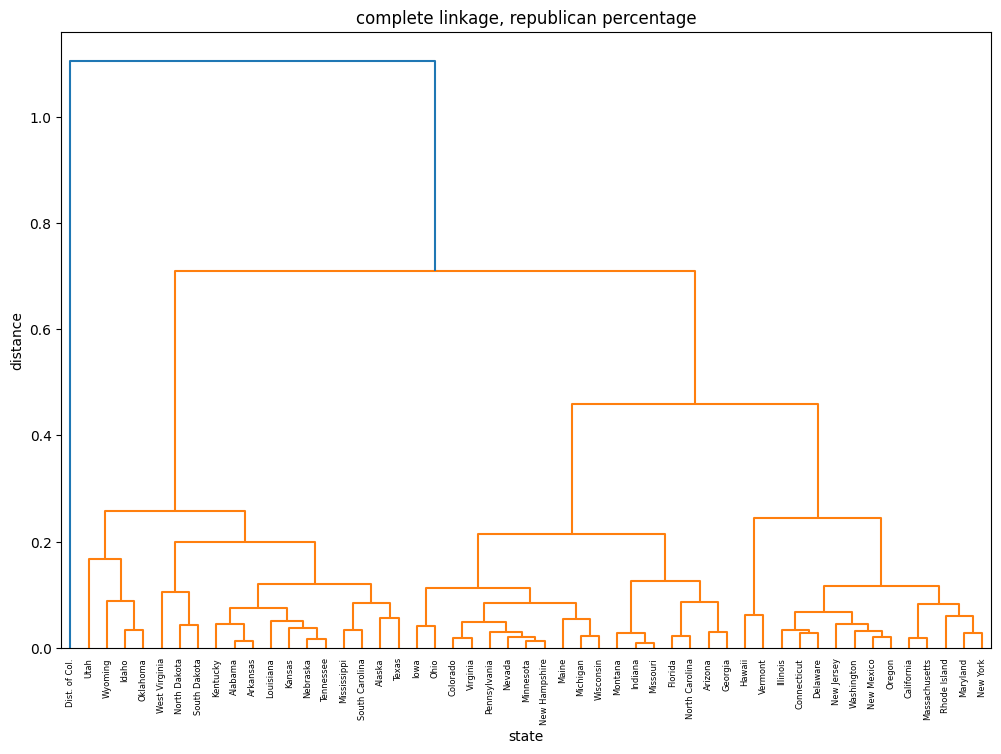

In [19]:
# Plot the dendrogram for the max proximity measure

# %%
# Plot the dendrogram for the max proximity measure
# Plot the dendrogram for the max proximity measure (Complete Linkage)

plt.figure(figsize=(12, 8))
max = linkage(df_X, method='complete')

dendrogram(max, labels=s_states.values, leaf_rotation=90)
plt.title("complete linkage, republican percentage")
plt.xlabel("state")
plt.ylabel("distance")
plt.show()


## Q3 Calculate the Cophenetic Correlation Coefficient (CPCC)

Using the data from question 2 (creating hierarchical clusters on the percentage of Republican votes), calculate the Cophenetic Correlation Coefficient for each of the three methods.  Display the results, and add a markdown cell explaining how to interpret this metric. You may use the scipy [cophenet function](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.cophenet.html) with the output from  [pdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html) function as the `Y` parameter. 

In [16]:
# Load the data, save off the state names into another series and just leave the attributes.
df_X = pd.read_csv('republican_percentage_by_state.csv')
s_states = df_X['State']
df_X = df_X.drop(columns=['State'])


ward = linkage(df_X, method='ward')
min = linkage(df_X, method='single')
max = linkage(df_X, method='complete')

ward_corr, ward_dist_mat = cophenet(ward, pdist(df_X))
min_corr, min_dist_mat = cophenet(min, pdist(df_X))
max_corr, max_dist_mat = cophenet(max, pdist(df_X))

print("Ward Correlation: " + str(ward_corr))
print("Min Correlation: " + str(min_corr))
print("Max Correlation: " + str(max_corr))


Ward Correlation: 0.5883071696030502
Min Correlation: 0.695463585768092
Max Correlation: 0.7406937703705782


It is showing how well the linkage matrix used to generate each cluster resembles the original data. A clustering algorithm that contains hierachy cluster that mixes distinct groups are given given low cophenet coefficent score. And a clustering algorithm where each heirachy cluster that contains the similar groups are given a high cophenent coefficent score. The max correlation generates hierachy bound that group similarity the best, while ward correlation generate hierachy generate bounds that perform the worst. It is used to determine how well your clustering algorithm performs. 

_explanation_

## Q4 Find new Clusters Based on K-Means

A political wonk has come to visit you in your data science dungeon, and looks over your shoulder.  They like what they see, and especially like the patterns from the Ward proximity diagram, and their team is going to come up with 4 different strategies based on the clustering that you have done.  But, your hierarchical clustering didn't come up with a natural 4 clusters! No problem, you decide to use k-means to come up with the 4 clusters.  You choose these points to initialize your cluster centers based on the Ward proximity graph in your hierarchical clusters:

  - Montana
  - Arkansas
  - Massachusetts
  - Minnesota

Pass `random_state = 23` into the [KMeans function](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).

Print out your centroids before you pass them to K-Means. Print out the States that are in each k-means cluster.

In [11]:
# Find the centroids

# %%
# Find the centroids
init = ["Montana", "Arkansas", "Massachusetts", "Minnesota"]
centroids = df_X[s_states.isin(init)].values



In [12]:
# Show the centroids
centroids

array([[0.62534252, 0.62154405, 0.60171721, 0.02362531],
       [0.33835509, 0.38214319, 0.36802922, 0.04378811],
       [0.47186924, 0.46058773, 0.44770625, 0.02416299],
       [0.5757692 , 0.57034232, 0.51169403, 0.06407517]])

In [13]:
# Compute the k-means clusters and show the listing of the States in each cluster

# %%
# Compute the k-means clusters and show the listing of the States in each cluster
kmeans = KMeans(
    n_clusters=4,
    init=centroids,
    n_init=1,
    random_state=23
)

kmeans.fit(df_X)
labels = kmeans.labels_

clusters = {}

for i, state in enumerate(s_states):
    curr_cluster = list(labels)[i]
    key = str(curr_cluster)

    if key not in clusters:
        clusters[key] = []

    clusters[key].append(state)

clusters

{'0': ['Alabama',
  'Arkansas',
  'Idaho',
  'Kentucky',
  'Nebraska',
  'North Dakota',
  'Oklahoma',
  'Tennessee',
  'Utah',
  'West Virginia',
  'Wyoming'],
 '3': ['Alaska',
  'Arizona',
  'Georgia',
  'Indiana',
  'Kansas',
  'Louisiana',
  'Mississippi',
  'Missouri',
  'Montana',
  'North Carolina',
  'South Carolina',
  'South Dakota',
  'Texas'],
 '1': ['California',
  'Dist. of Col.',
  'Hawaii',
  'Maryland',
  'Massachusetts',
  'New York',
  'Rhode Island',
  'Vermont'],
 '2': ['Colorado',
  'Connecticut',
  'Delaware',
  'Florida',
  'Illinois',
  'Iowa',
  'Maine',
  'Michigan',
  'Minnesota',
  'Nevada',
  'New Hampshire',
  'New Jersey',
  'New Mexico',
  'Ohio',
  'Oregon',
  'Pennsylvania',
  'Virginia',
  'Washington',
  'Wisconsin']}

## Q5 Visualize the Silhouette Coefficients for Each Cluster

Using the [Silhouette Coefficient](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_samples.html) implementation in sci-kit learn, calculate the silhouette coefficient for each of the States in our data frame using the clustering from Q4, and create a bar graph, similar to the [left plot in this link](https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html).

Use the Silhouette Coefficient plot to identify clusters that have outliers.  Describe in a markdown cells how the visualization helped you identify the outlier points.  

For n_clusters = 4 The average silhouette_score is : 0.363343902467516


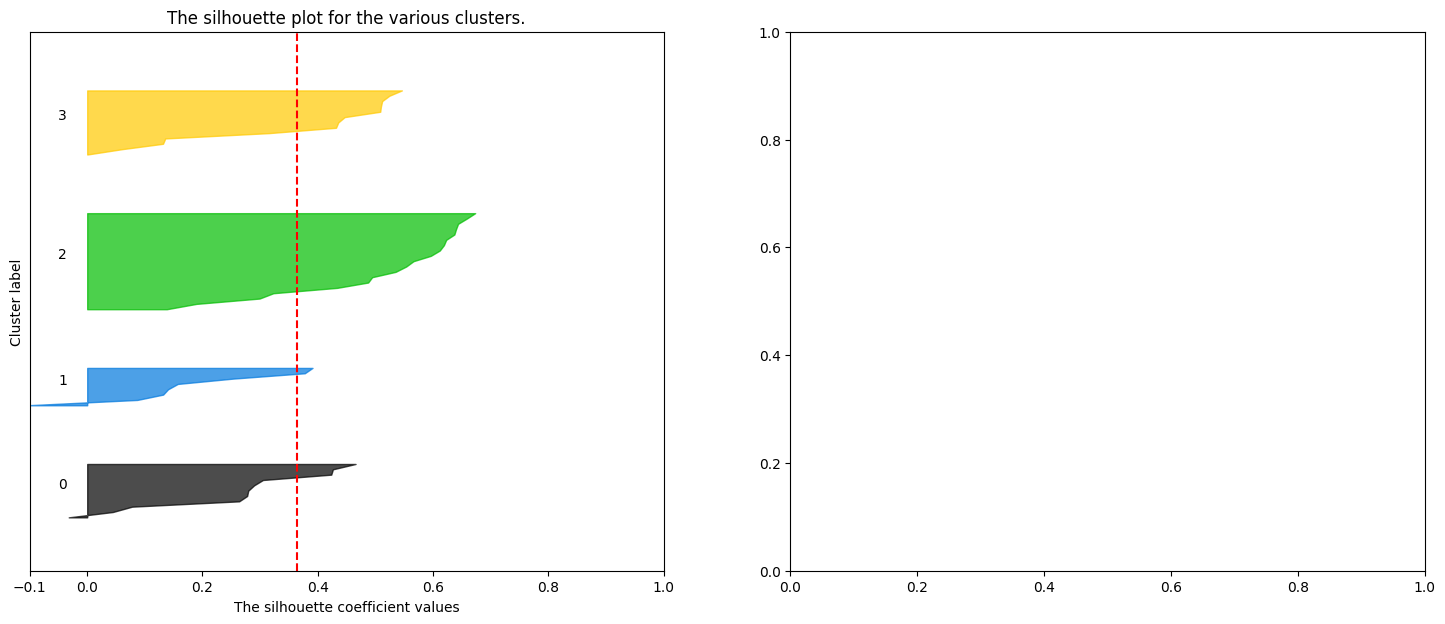

In [32]:
from sklearn.metrics import silhouette_samples, silhouette_score

n_clusters = len(clusters)

# Create a subplot with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

# The 1st subplot is the silhouette plot
# The silhouette coefficient can range from -1, 1 but in this example all
# lie within [-0.1, 1]
ax1.set_xlim([-0.1, 1])
# The (n_clusters+1)*10 is for inserting blank space between silhouette
# plots of individual clusters, to demarcate them clearly.
ax1.set_ylim([0, len(df_X) + (n_clusters + 1) * 10])

# # Initialize the clusterer with n_clusters value and a random generator
# # seed of 10 for reproducibility.
# clusterer = KMeans(n_clusters=n_clusters, random_state=10)
# cluster_labels = clusterer.fit_predict(X) # use labels

# The silhouette_score gives the average value for all the samples.
# This gives a perspective into the density and separation of the formed
# clusters
silhouette_avg = silhouette_score(df_X, labels)
print(
    "For n_clusters =",
    n_clusters,
    "The average silhouette_score is :",
    silhouette_avg,
)

# Compute the silhouette scores for each sample
sample_silhouette_values = silhouette_samples(df_X, labels)

y_lower = 10
for i in range(n_clusters):
    # Aggregate the silhouette scores for samples belonging to
    # cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]

    ith_cluster_silhouette_values.sort()


    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_silhouette_values,
        facecolor=color,
        edgecolor=color,
        alpha=0.7,
    )

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    # Compute the new y_lower for next plot
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("The silhouette plot for the various clusters.")
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster label")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

ax1.set_yticks([])  # Clear the yaxis labels / ticks
ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])


Cluster one and zero have outliers. Sihouette score is defined between the range of [-1, 1] where the negative number indicate that the point is in the wrong cluster and the positive number indiciate that point is in the correct cluster. The visualization graphs allow you to pickup clusters that contain negative score, which indicates that there is an outlier in that cluster.

_description of the graph, and how you used it to detect outliers, and what the outliers you found are (tell me the states)_